# AI-Based Phishing URL Detection — STEP 5: URL Feature Extraction

Notebook ini menerapkan fungsi ekstraksi fitur dari `src/feature_extraction.py` ke dataset bersih hasil STEP 1-2.

**Prinsip di notebook ini:** logic ekstraksi fitur ditulis di `src/feature_extraction.py` (reusable, terdokumentasi), notebook ini hanya **memanggil** fungsi tersebut dan mengeksplorasi hasilnya — bukan tempat menulis logic baru.

**Cara pakai:**
- Pastikan `data/processed/phishing_urls_clean.csv` sudah ada (hasil STEP 1-2).
- Pastikan `src/feature_extraction.py` ada di folder `src/` pada level yang sama dengan folder `notebooks/`.

## 1. Import & Load Data

In [7]:
import sys
sys.path.append('../src')

import pandas as pd
from feature_extraction import extract_features

df = pd.read_csv('../data/processed/phishing_urls_clean.csv')
print("Shape data bersih:", df.shape)
df.head()

Shape data bersih: (507080, 5)


,URL,Label,url_length,dot_count,digit_count
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,225,6,58
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,81,5,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,177,7,47
3,mail.printakid.com/www.online.americanexpress....,bad,60,6,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,116,1,21


## 2. Ekstraksi Fitur

Menerapkan 8 fungsi ekstraksi fitur (`url_length`, `dot_count`, `digit_count`, `hyphen_count`, `special_char_count`, `has_at_symbol`, `subdomain_count`, `has_ip_address`) ke setiap URL.

In [8]:
features_df = extract_features(df, url_col='URL')
features_df['Label'] = df['Label'].values

print("Shape hasil ekstraksi fitur:", features_df.shape)
features_df.head(10)

Shape hasil ekstraksi fitur: (507080, 9)


,url_length,dot_count,digit_count,hyphen_count,special_char_count,has_at_symbol,subdomain_count,has_ip_address,Label
0,225,6,58,4,16,0,0,0,bad
1,81,5,1,2,6,0,1,0,bad
2,177,7,47,1,1,0,0,0,bad
3,60,6,0,0,0,0,1,0,bad
4,116,1,21,1,2,0,0,0,bad
5,36,3,0,0,0,0,1,0,bad
6,61,2,7,3,3,0,0,0,bad
7,60,5,4,0,0,0,0,0,bad
8,19,1,4,0,0,0,0,0,bad
9,193,4,35,3,12,0,0,0,bad


## 3. Statistik Fitur per Label

Cek ringkasan statistik tiap fitur, dipisah per kelas — memverifikasi apakah pola yang kita lihat di EDA (STEP 2) konsisten setelah diekstrak jadi fitur numerik penuh.

In [9]:
features_df.groupby('Label').mean(numeric_only=True)

,url_length,dot_count,digit_count,hyphen_count,special_char_count,has_at_symbol,subdomain_count,has_ip_address
Label,,,,,,,,
bad,71.08155,3.009681,10.286751,0.719122,3.016333,0.014293,0.864393,0.031895
good,45.76679,1.782130,3.133869,1.332433,2.368314,0.000583,0.374319,0.000064


## 4. Cek Missing Value & Tipe Data Hasil Ekstraksi

Pastikan tidak ada NaN yang tidak sengaja muncul dari proses parsing URL (misalnya hostname gagal di-parse).

In [10]:
print(features_df.isnull().sum())
print()
print(features_df.dtypes)

url_length            0
dot_count             0
digit_count           0
hyphen_count          0
special_char_count    0
has_at_symbol         0
subdomain_count       0
has_ip_address        0
Label                 0
dtype: int64

url_length             int64
dot_count              int64
digit_count            int64
hyphen_count           int64
special_char_count     int64
has_at_symbol          int64
subdomain_count        int64
has_ip_address         int64
Label                 object
dtype: object


## 5. Korelasi Antar Fitur

Penting untuk STEP 6 nanti — fitur yang berkorelasi sangat tinggi berpotensi redundan, terutama untuk model linear seperti Logistic Regression.

                    url_length  dot_count  digit_count  hyphen_count  \
url_length                1.00       0.49         0.76          0.43   
dot_count                 0.49       1.00         0.43         -0.03   
digit_count               0.76       0.43         1.00          0.19   
hyphen_count              0.43      -0.03         0.19          1.00   
special_char_count        0.76       0.24         0.44          0.55   
has_at_symbol             0.08       0.10         0.05         -0.01   
subdomain_count           0.28       0.73         0.35         -0.03   
has_ip_address           -0.04       0.08         0.07         -0.04   

                    special_char_count  has_at_symbol  subdomain_count  \
url_length                        0.76           0.08             0.28   
dot_count                         0.24           0.10             0.73   
digit_count                       0.44           0.05             0.35   
hyphen_count                      0.55          -0.01  

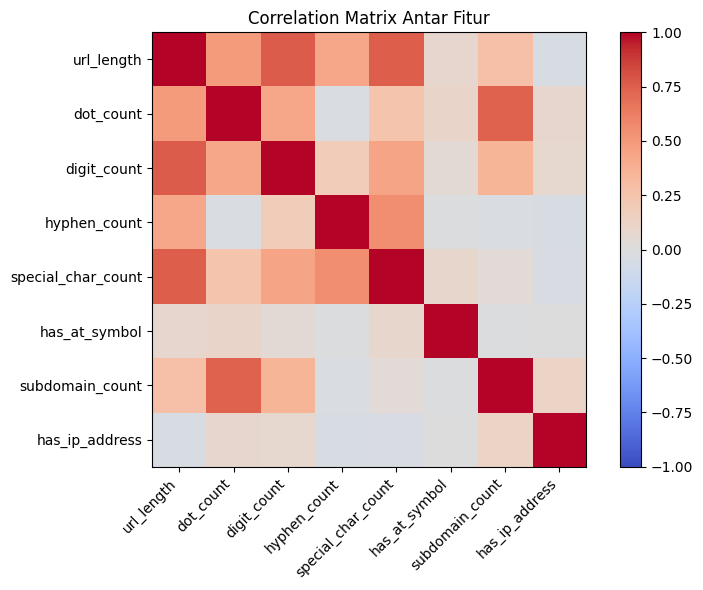

In [11]:
import matplotlib.pyplot as plt

corr = features_df.drop(columns='Label').corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
plt.title('Correlation Matrix Antar Fitur')
plt.tight_layout()
plt.show()

In [12]:
features_df.to_csv('../data/processed/phishing_features.csv', index=False)
print("Tersimpan:", features_df.shape)

Tersimpan: (507080, 9)
